# Churn Prediction model

####

**Business goal.** User activity is declining. We want to identify players **at risk of leaving (churn)** so the business team can act (bonuses, direct outreach, reactivation). The deliverable the business consumes is a **ranked risk list**, not a raw yes/no label.

**Churn Definition from Data_Dictionary**
|||
|---|---|
| Observation window | `2025-10-03` → `2025-12-31` (measured behaviour timewindow ) |
| Outcome window | the next **30 days** after `2025-12-31`
| `churn = 1` | player places **no** live bets in the outcome window |

Reusable logic lives in the `src/` package so this notebook is only for narrative representation.

## 0.0 Imports

In [1]:
from pathlib import Path
import sys, os
PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import warnings; warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config as cfg
from src.data import load_raw, load_clean, iqr_outlier_summary, plot_distr
from src.features import add_features, build_feature_matrix
from src import evaluate as ev

## 1.0 Data loading and first look

In [5]:
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 60)

In [6]:
raw = load_raw()
print("shape:", raw.shape)
raw.head(10).T

shape: (10000, 21)


,0,1,2,3,4,5,6,7,8,9
user_id,USER_10000,USER_10001,USER_10002,USER_10003,USER_10004,USER_10005,USER_10006,USER_10007,USER_10008,USER_10009
registration_date,2025-06-23 00:00:00,2024-08-28 00:00:00,2024-08-05 00:00:00,2024-09-17 00:00:00,2024-09-09 00:00:00,2025-04-01 00:00:00,2024-09-19 00:00:00,2024-06-13 00:00:00,2021-05-04 00:00:00,2025-01-24 00:00:00
observation_start_date,2025-10-03 00:00:00,2025-10-03 00:00:00,2025-10-03 00:00:00,2025-10-03 00:00:00,2025-10-03 00:00:00,2025-10-03 00:00:00,2025-10-03 00:00:00,2025-10-03 00:00:00,2025-10-03 00:00:00,2025-10-03 00:00:00
observation_end_date,2025-12-31 00:00:00,2025-12-31 00:00:00,2025-12-31 00:00:00,2025-12-31 00:00:00,2025-12-31 00:00:00,2025-12-31 00:00:00,2025-12-31 00:00:00,2025-12-31 00:00:00,2025-12-31 00:00:00,2025-12-31 00:00:00
last_live_bet_date,2025-12-26 00:00:00,2025-12-21 00:00:00,2025-12-28 00:00:00,2025-12-31 00:00:00,2025-12-30 00:00:00,2025-12-29 00:00:00,2025-12-26 00:00:00,2025-12-31 00:00:00,2025-12-29 00:00:00,2025-12-30 00:00:00
first_live_bet_date,2025-10-05 00:00:00,2025-10-15 00:00:00,2025-10-06 00:00:00,2025-10-12 00:00:00,2025-10-08 00:00:00,2025-10-03 00:00:00,2025-10-04 00:00:00,2025-10-06 00:00:00,2025-10-11 00:00:00,2025-10-04 00:00:00
tenure_days,191,490,513,470,478,274,468,566,1702,341
live_bets_count,46,43,40,86,82,128,142,57,67,21
avg_bet_amount,2.03,5.22,7.07,NaN,3.05,6.07,NaN,5.13,6.69,5.13
total_turnover,93.38,224.46,282.8,890.1,250.1,776.96,1211.26,292.41,448.23,107.73


In [7]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   user_id                         10000 non-null  str           
 1   registration_date               10000 non-null  datetime64[us]
 2   observation_start_date          10000 non-null  datetime64[us]
 3   observation_end_date            10000 non-null  datetime64[us]
 4   last_live_bet_date              9999 non-null   datetime64[us]
 5   first_live_bet_date             9999 non-null   datetime64[us]
 6   tenure_days                     10000 non-null  int64         
 7   live_bets_count                 10000 non-null  int64         
 8   avg_bet_amount                  9310 non-null   float64       
 9   total_turnover                  10000 non-null  float64       
 10  total_payout                    10000 non-null  float64       
 11  ggr           

## 2. Exploratory Data Analysis

In [8]:
sns.set_theme(style="whitegrid", palette="deep")

Here I will check descriptive statiscis for numerical part of the data.

In [9]:
num_cols = raw.select_dtypes("number").columns.difference(["live_bets_count_outcome_window", cfg.TARGET])

display(raw[num_cols].describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
avg_bet_amount,9310.0,10.81,7.41,1.01,5.88,8.91,13.48,101.97
bet_day_rate,10000.0,0.21,0.10,0.00,0.13,0.19,0.27,0.67
days_active_in_observation,10000.0,18.57,8.70,0.00,12.00,17.00,24.00,60.00
days_since_last_bet,10000.0,4.92,6.69,0.00,1.00,3.00,6.00,90.00
deposit_count,9498.0,3.13,1.87,0.00,2.00,3.00,4.00,12.00
deposit_to_turnover_ratio,9497.0,0.96,0.58,0.00,0.74,0.96,1.18,36.54
ggr,10000.0,269.34,418.41,-1888.39,51.79,156.66,344.84,7221.17
ggr_margin,9999.0,0.39,0.29,-0.57,0.18,0.41,0.62,0.90
live_bets_count,10000.0,63.97,42.27,0.00,32.00,54.00,86.00,293.00
tenure_days,10000.0,591.00,445.04,50.00,225.00,463.50,847.00,2035.00



* **"Money group":** Here it can be seen that data have **Heavy right skew / big outliers**: especially for `total turnover`, `total_payout`, `total_deposit`, `total_deposit_amount`, `ggr`, `avg_bet_amount`. All of their values roughly is considerably higher in their 75th percentile. This will be analysed further down the line.
* `ggr` has negative values in min section (-1888.39), and it is expected since players can win net. So this minus is not a problem in this case.
* `deposit_to_turnover_ration` is centered near 1 (mean 0.96, median 0.96, IQR 0.74–1.18), meaning deposits ≈ turnover for most players. The max of 36.54 is a strong right tail outlier (deposited far more than wagered), and the min of 0 reflects players with no deposit record. Still candidate for outlier analysis.
* `days_since_last_bet` is strongly right skewed: median 3 and 75th percentile 6, but max 90. Most players bet recently, with a thin tail of idle players out to 90 days. Std (6.69) > mean (4.92) confirms the skew. This is the core recency signal by RFM framework and probably strongest churn driver.

### 2.1 Missing values


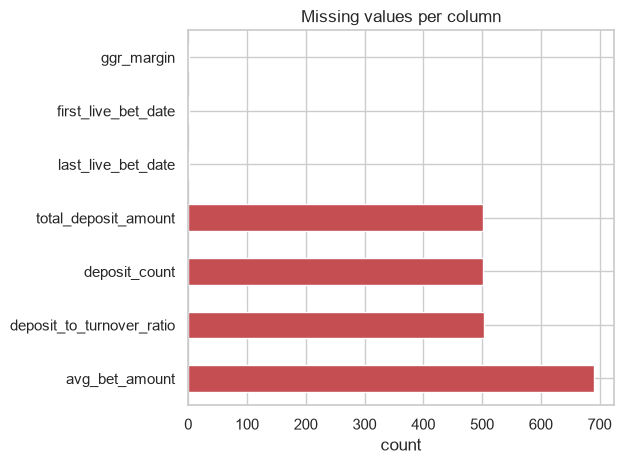


Missing values by column:
                           missing_count  missing_pct
avg_bet_amount                       690         6.90
deposit_to_turnover_ratio            503         5.03
deposit_count                        502         5.02
total_deposit_amount                 502         5.02
last_live_bet_date                     1         0.01
first_live_bet_date                    1         0.01
ggr_margin                             1         0.01

deposit_count == 0 rows : 489
deposit_count NaN  rows : 502
max |avg_bet - turnover/count| on known rows: 0.00


In [10]:
miss = raw.isna().sum() 
miss = miss[miss>0].sort_values(ascending=False)

ax = miss.plot.barh(color="#C44E52")
# ax.set_xscale("log")
ax.set_title("Missing values per column") 
ax.set_xlabel("count")

plt.tight_layout()
plt.show()

miss_report = pd.DataFrame({
    "missing_count": miss,
    "missing_pct": (miss / len(raw) * 100).round(2),
})

print("\nMissing values by column:")
print(miss_report.to_string())

# Proof that NaN != 0 for deposits, and that avg_bet is recoverable:
print("\ndeposit_count == 0 rows :", int((raw.deposit_count==0).sum()))
print("deposit_count NaN  rows :", int(raw.deposit_count.isna().sum()))

recon = raw.total_turnover / raw.live_bets_count.replace(0, np.nan)
mask = raw.avg_bet_amount.notna() & (raw.live_bets_count>0)

# print("max |avg_bet - turnover/count| on known rows:", float((recon[mask]-raw.avg_bet_amount[mask]).abs().max())) 

max_err = (recon[mask] - raw.avg_bet_amount[mask]).abs().max()
print(f"max |avg_bet - turnover/count| on known rows: {max_err:.2f}")

Two *different* kinds of missing data are handled differently in `src/data.py`:

* **`avg_bet_amount`** is missing (690) and the dictionary defines it as `total_turnover / live_bets_count`. That identity holds exactly on the known rows, so we **reconstruct** the missing values (no information loss) rather than to mean impute.
* **Deposit columns** is missing (~500), here `NaN` and `0` *coexist*, so `NaN` genuinely means *unknown*, not zero. I added a **`deposit_info_missing` flag** (so the model can use "no deposit record" as a signal) and fill with **Deposit columns** with 0.
* Other 3 **[last_live_bet_date** | **First_live_bet_date** | **ggr_margin]** have only 1 missing value which is neglectable.

### 2.2 Target Distribution

* Churn is the minority class: **17.3%** churn vs 82.7% active.
* This sets a hard baseline: a trivial "never churns" model scores **82.7% accuracy**
  while catching **zero** churners. So accuracy is disqualified as a selection metric.

* **Decisions this drives:**
    * **Primary metric = PR-AUC** (sensitive to the minority class), with **ROC-AUC**
      as a secondary ranking metric and **lift @ top-k** as the business facing metric.

    * **Handle imbalance in model** (`class_weight="balanced"` for LogReg,
      `scale_pos_weight`/balanced for LightGBM) rather than resampling the imbalance
      is mild enough that reweighting is sufficient and keeps probabilities calibratable.

    * Stratify the train/test split and CV folds on the target to preserve the 17.3% rate.

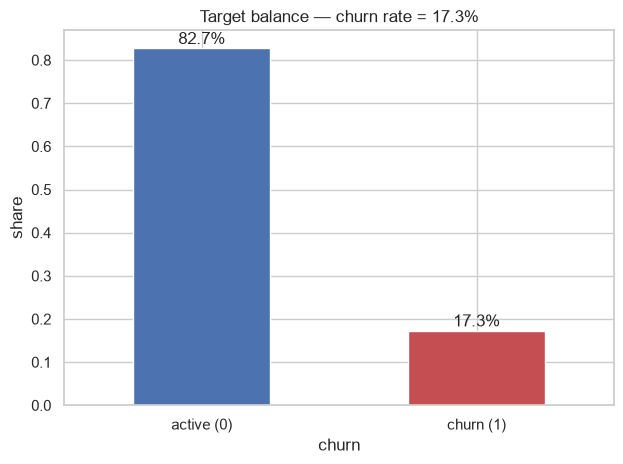

In [11]:
ax = raw[cfg.TARGET].value_counts(normalize=True).sort_index().plot.bar(color=["#4C72B0","#C44E52"])

ax.set_xticklabels(["active (0)","churn (1)"], rotation=0)
ax.set_ylabel("share")

ax.set_title(f"Target balance — churn rate = {raw[cfg.TARGET].mean():.1%}")
for i,v in enumerate(raw[cfg.TARGET].value_counts(normalize=True).sort_index()):
    ax.text(i, v+0.01, f"{v:.1%}", ha="center")
    
plt.tight_layout() 
plt.show()

### 2.3 Distribution of monetary variables

* The **monetary group** (`total_turnover`, `total_payout`, `total_deposit_amount`,
  `avg_bet_amount`, `ggr`) is heavily **right skewed**  a thin high roller tail with the
  mass near zero. This matches the descriptive stats (mean ≫ median).
* **`ggr` is the exception in sign, not shape:** it has a real **negative tail**
  (net-winning players down to ≈ -1888), so any transform must be sign-safe.
* **`live_bets_count` is the exception in shape:** unimodal with a moderate tail, **not** extreme skewed, so it needs no transform.

* **Decisions (closed):**
    * **LightGBM:** no transform tree splits are scale/skew invariant.
    * **Linear baseline:** apply **`log1p` to the positive monetary columns**
      (turnover, payout, deposit, avg_bet) inside the pipeline to tame leverage.
      leave `ggr` on a **signed transform** (e.g. `sign(x)·log1p(|x|)`) or standardize only,
      since `log1p` can't take negatives.
    * Transforms live in the modeling pipeline (fit on train only) **no leakage**.

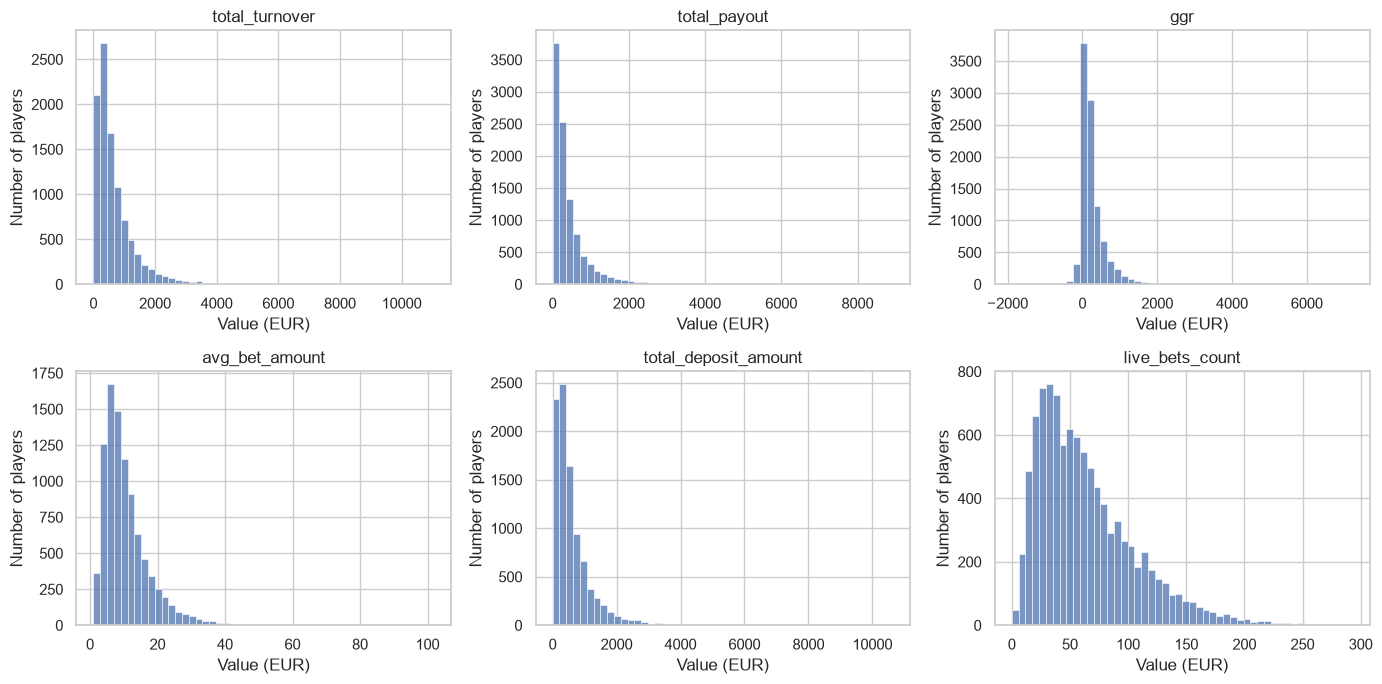

In [12]:
money = ["total_turnover","total_payout","ggr","avg_bet_amount","total_deposit_amount","live_bets_count"]

fig, axes = plt.subplots(2,3, figsize=(14,7))

for ax,col in zip(axes.ravel(), money):
    sns.histplot(raw[col].dropna(), bins=50, ax=ax, color="#4C72B0")
    ax.set_title(col) 
    ax.set_xlabel("Value (EUR)")
    ax.set_ylabel("Number of players")

plt.tight_layout()
plt.show()

### 2.4 Outlier analysis

In [13]:
outlier_summary, outlier_mask = iqr_outlier_summary(raw, num_cols, k=1.5)

display(outlier_summary.round(3))

,feature,n_valid,q1,q3,iqr,lower_bound,upper_bound,n_outliers,outlier_%
0,days_since_last_bet,10000,1.000,6.000,5.000,-6.500,13.500,853,8.530
1,total_payout,10000,118.455,512.655,394.200,-472.845,1103.955,803,8.030
2,ggr,10000,51.787,344.842,293.055,-387.795,784.425,776,7.760
3,total_deposit_amount,9498,215.965,779.990,564.025,-630.073,1626.028,649,6.833
4,total_turnover,10000,250.543,871.605,621.062,-681.051,1803.199,650,6.500
5,deposit_to_turnover_ratio,9497,0.735,1.178,0.443,0.070,1.843,613,6.455
6,avg_bet_amount,9310,5.882,13.478,7.595,-5.510,24.870,453,4.866
7,live_bets_count,10000,32.000,86.000,54.000,-49.000,167.000,272,2.720
8,deposit_count,9498,2.000,4.000,2.000,-1.000,7.000,195,2.053
9,tenure_days,10000,225.000,847.000,622.000,-708.000,1780.000,136,1.360


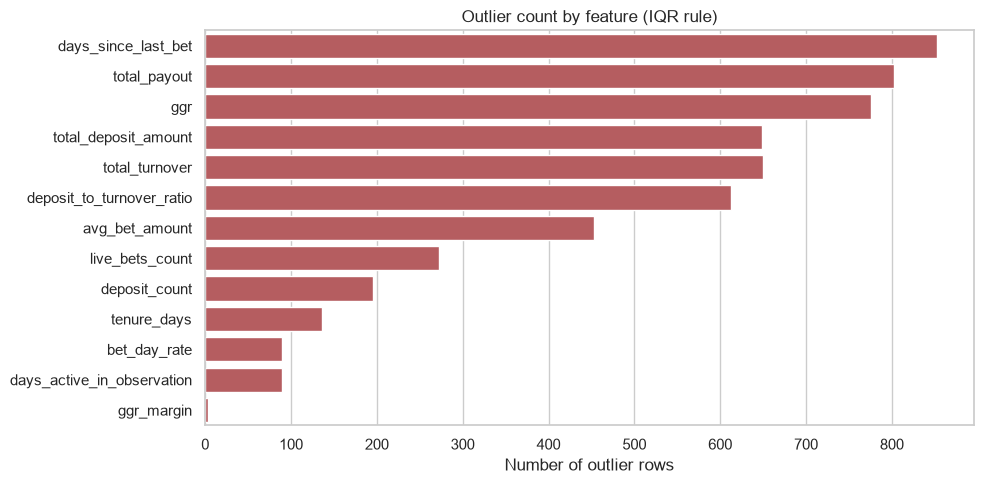

In [14]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=outlier_summary,
    y="feature",
    x="n_outliers",
    color="#C44E52"
)

plt.title("Outlier count by feature (IQR rule)")
plt.xlabel("Number of outlier rows")
plt.ylabel("")
plt.tight_layout()
plt.show()

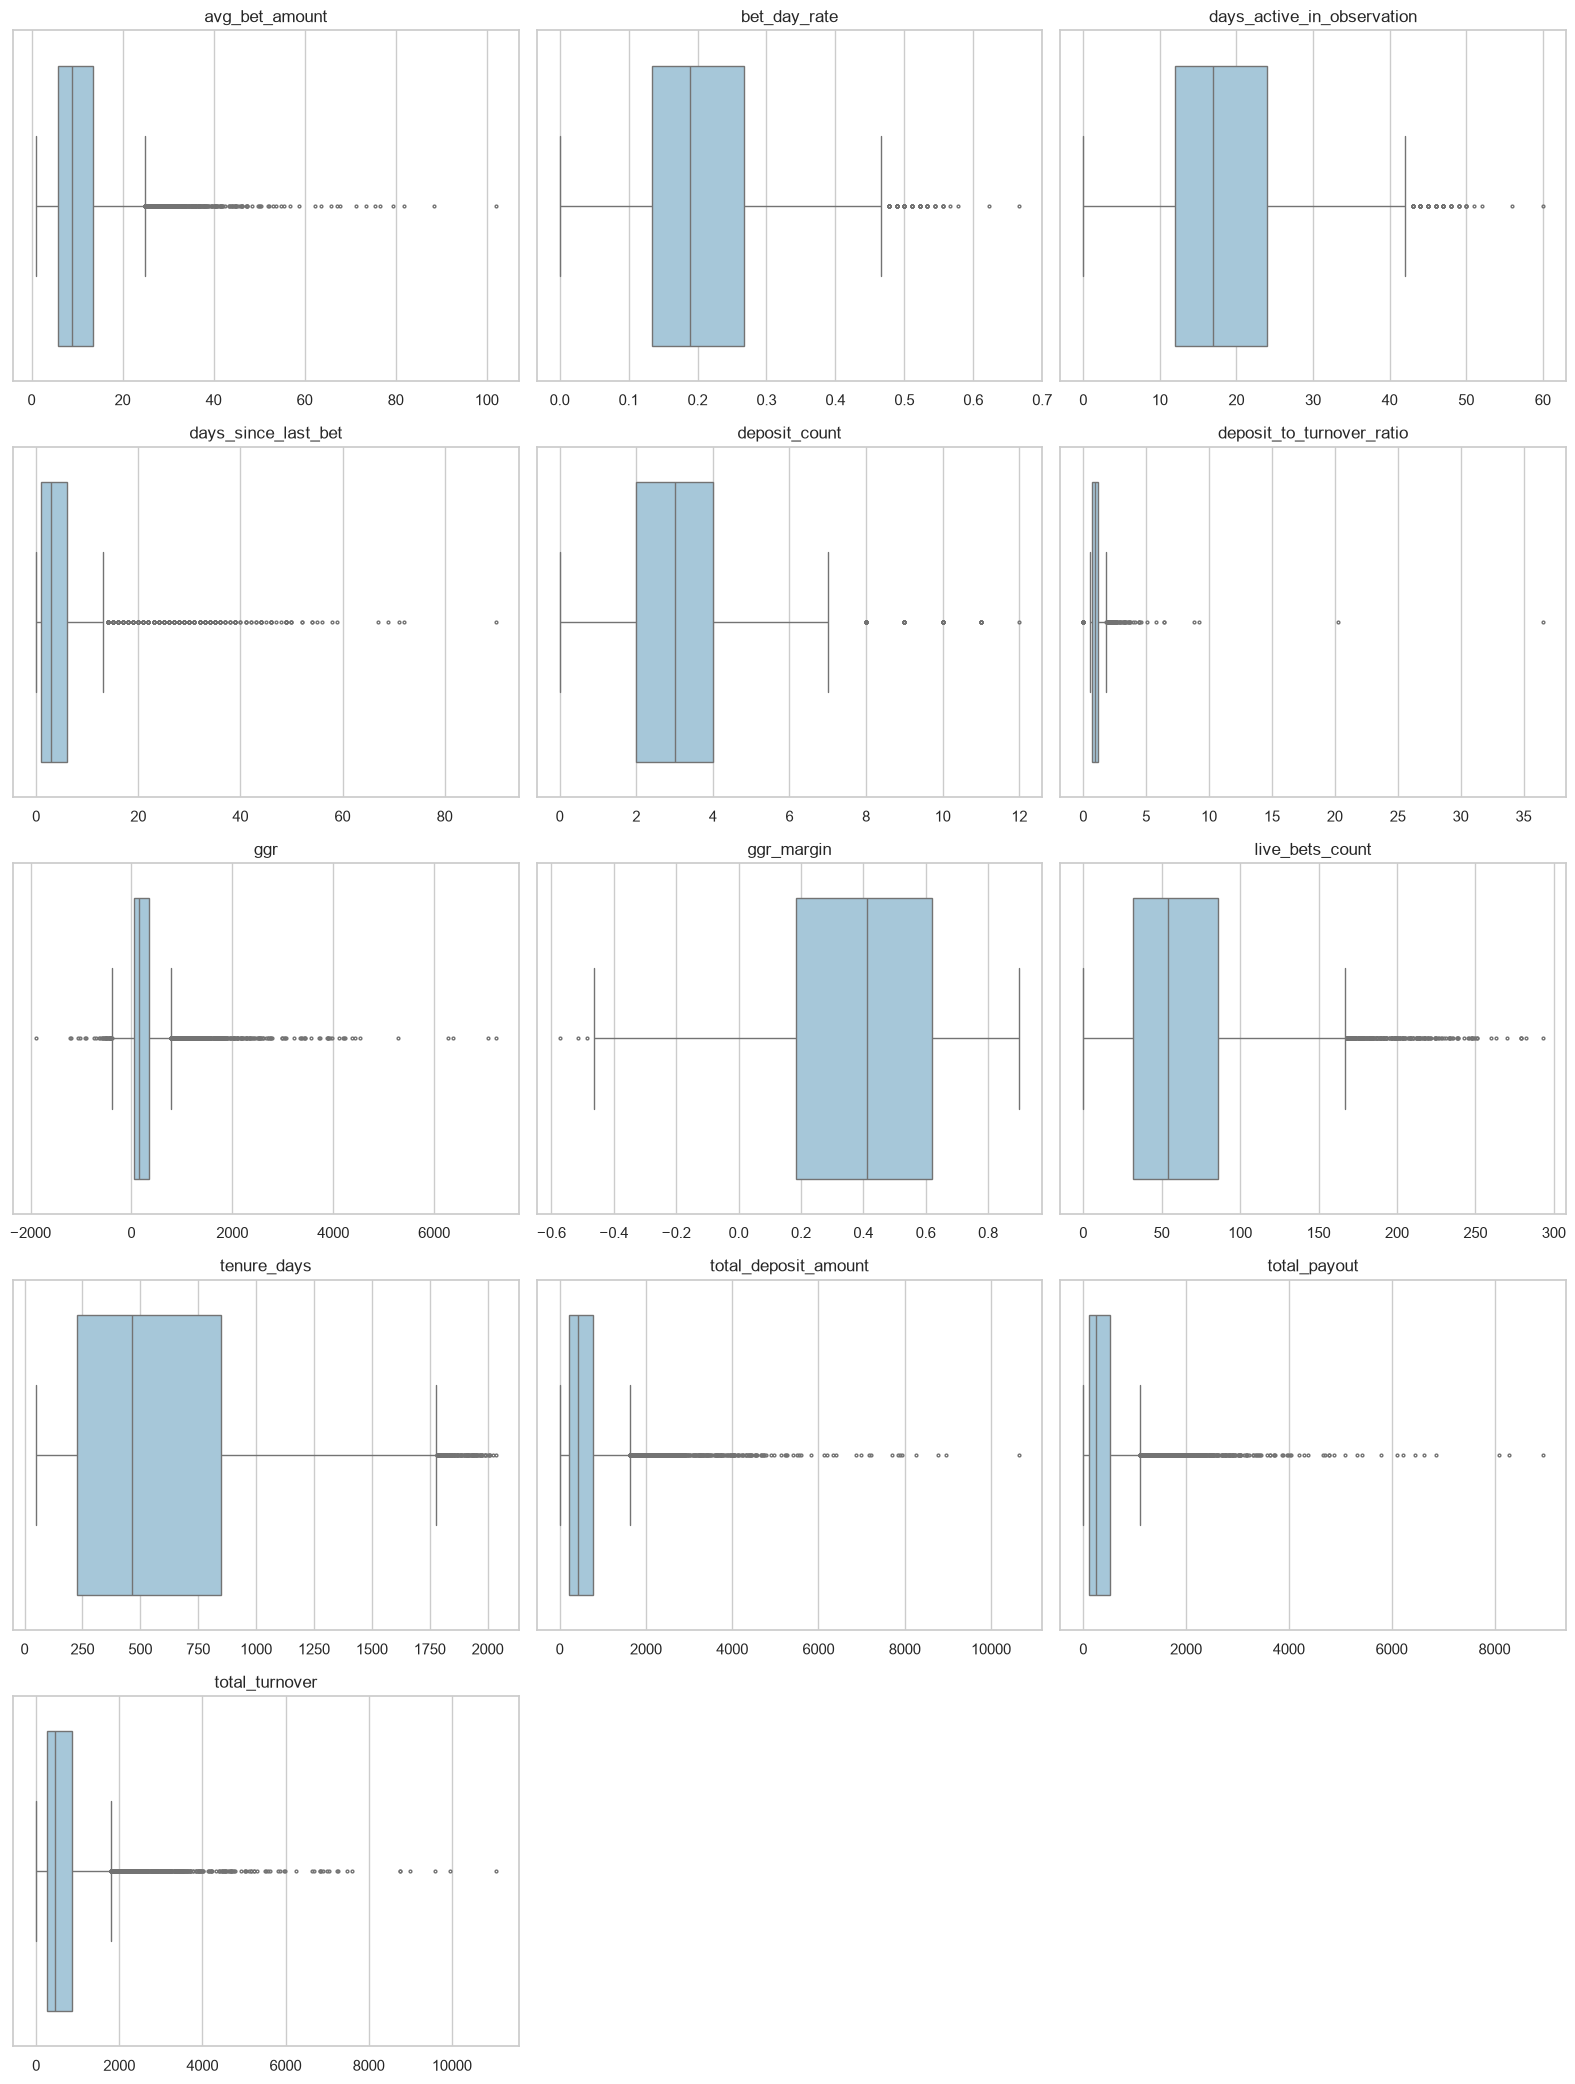

In [15]:
n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.2 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=raw[col],
        ax=axes[i],
        color="#9ecae1",
        fliersize=2,
        linewidth=1
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# hide empty panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Outlier findings (IQR rule, k=1.5)**

* Every features outliers sit on the **upper tail** (all `lower_bound` values are negative or ~0, and the box plots show whiskers/points extending only to the right). This confirms the **right skew** seen in the statistics. Confirming that these are heavy players, not data errors.
* **Highest outlier share is `days_since_last_bet` (8.53%)**. This is expected and **kept**: it is the recency signal, and the idle tail (out to 90 days) is exactly the churn risk segment. Confirming that it is not noise.
* **Money group** — `total_payout` (8.03%), `ggr` (7.76%), `total_deposit_amount` (6.83%), `total_turnover` (6.50%), `avg_bet_amount` (4.87%) all show the same high roller tail. These are **legitimate business extremes**, so they are retained.
* **`deposit_to_turnover_ratio` (6.46%)** includes the extreme max (36.54) flagged earlier. It is a real behavioral anomaly (deposited >> wagered), I think this is worth keeping as signal.
* **`live_bets_count` (2.72%)** and **`deposit_count` (2.05%)** have modest tails, consistent with count variables.
* **`tenure_days` (1.36%)** outliers are veteran players therefore not error.
* **`bet_day_rate` / `days_active_in_observation` (0.89%)** are well behaved. Box plots show compact boxes.
* **`ggr_margin` (0.03%, only 3 rows)** is effectively clean and bounded.

**Decision:** These outliers are **genuine player behavior, not data quality issues**, so I will **not remove or clip** them.
* **LightGBM** is tree based and split based, so it is robust to these tails natively.
* For the **linear baseline**, I will mitigate their leverage via **standardization + a log transform** on the heavy monetary columns rather than deletion.

### 2.5 Distributions

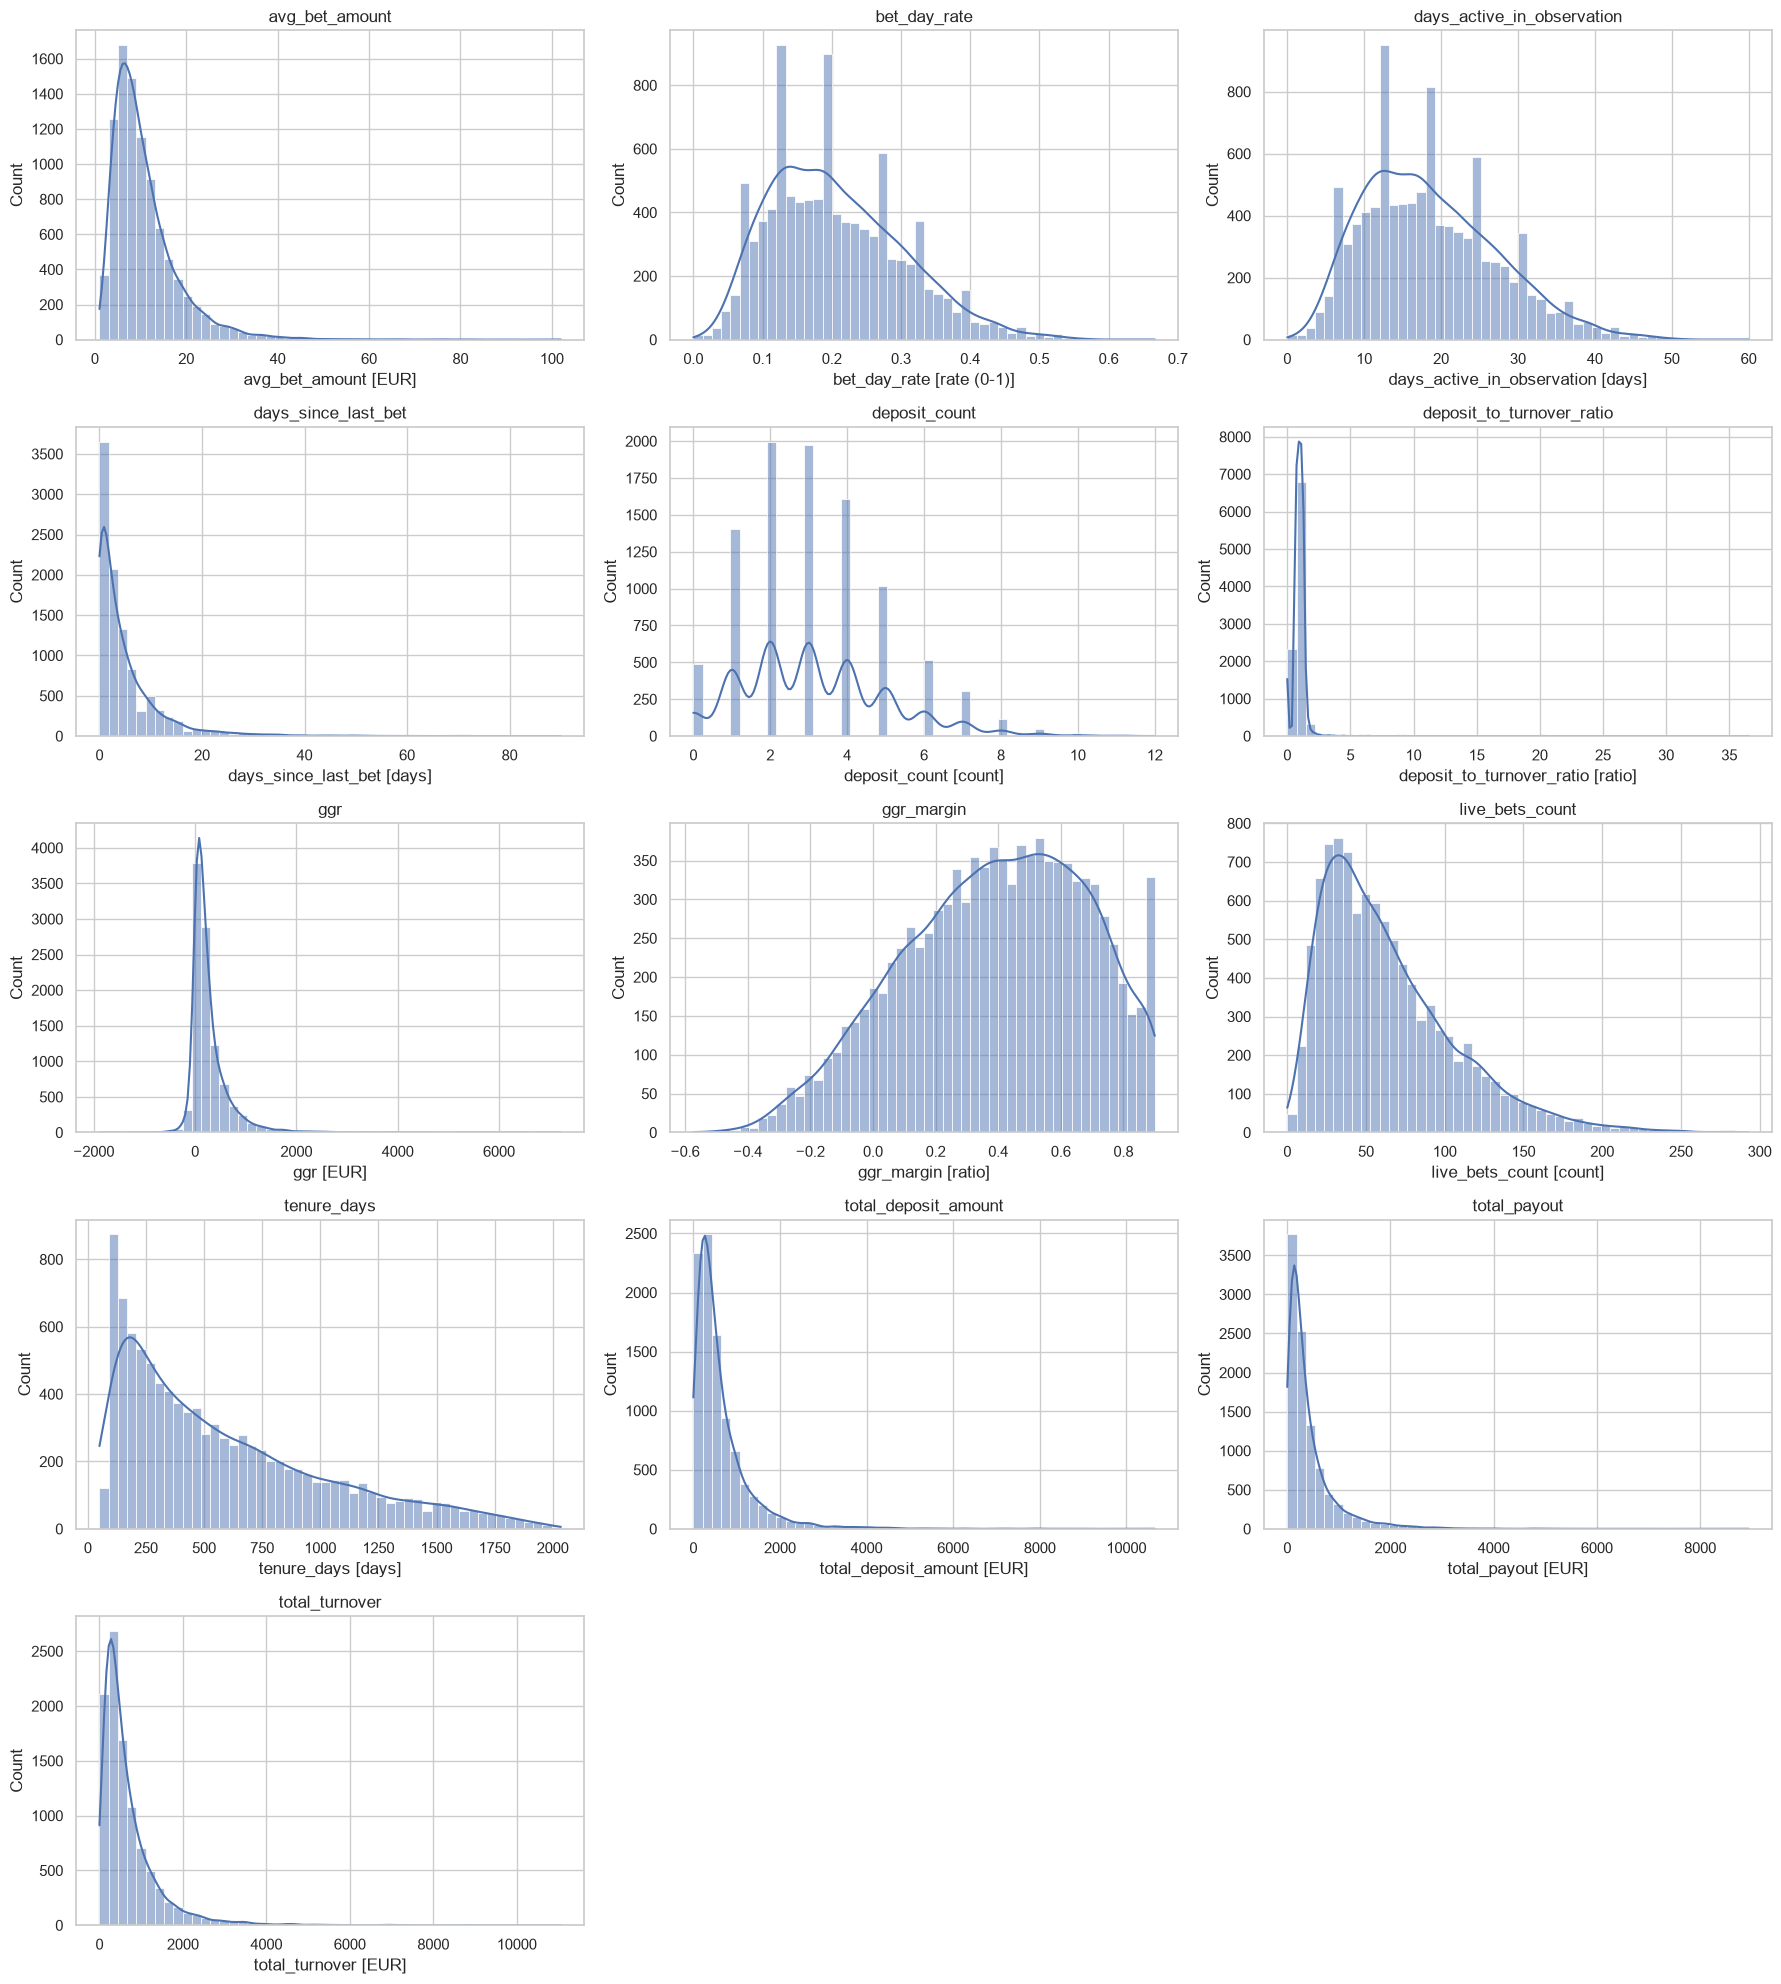

In [16]:
plot_distr(raw, num_cols)


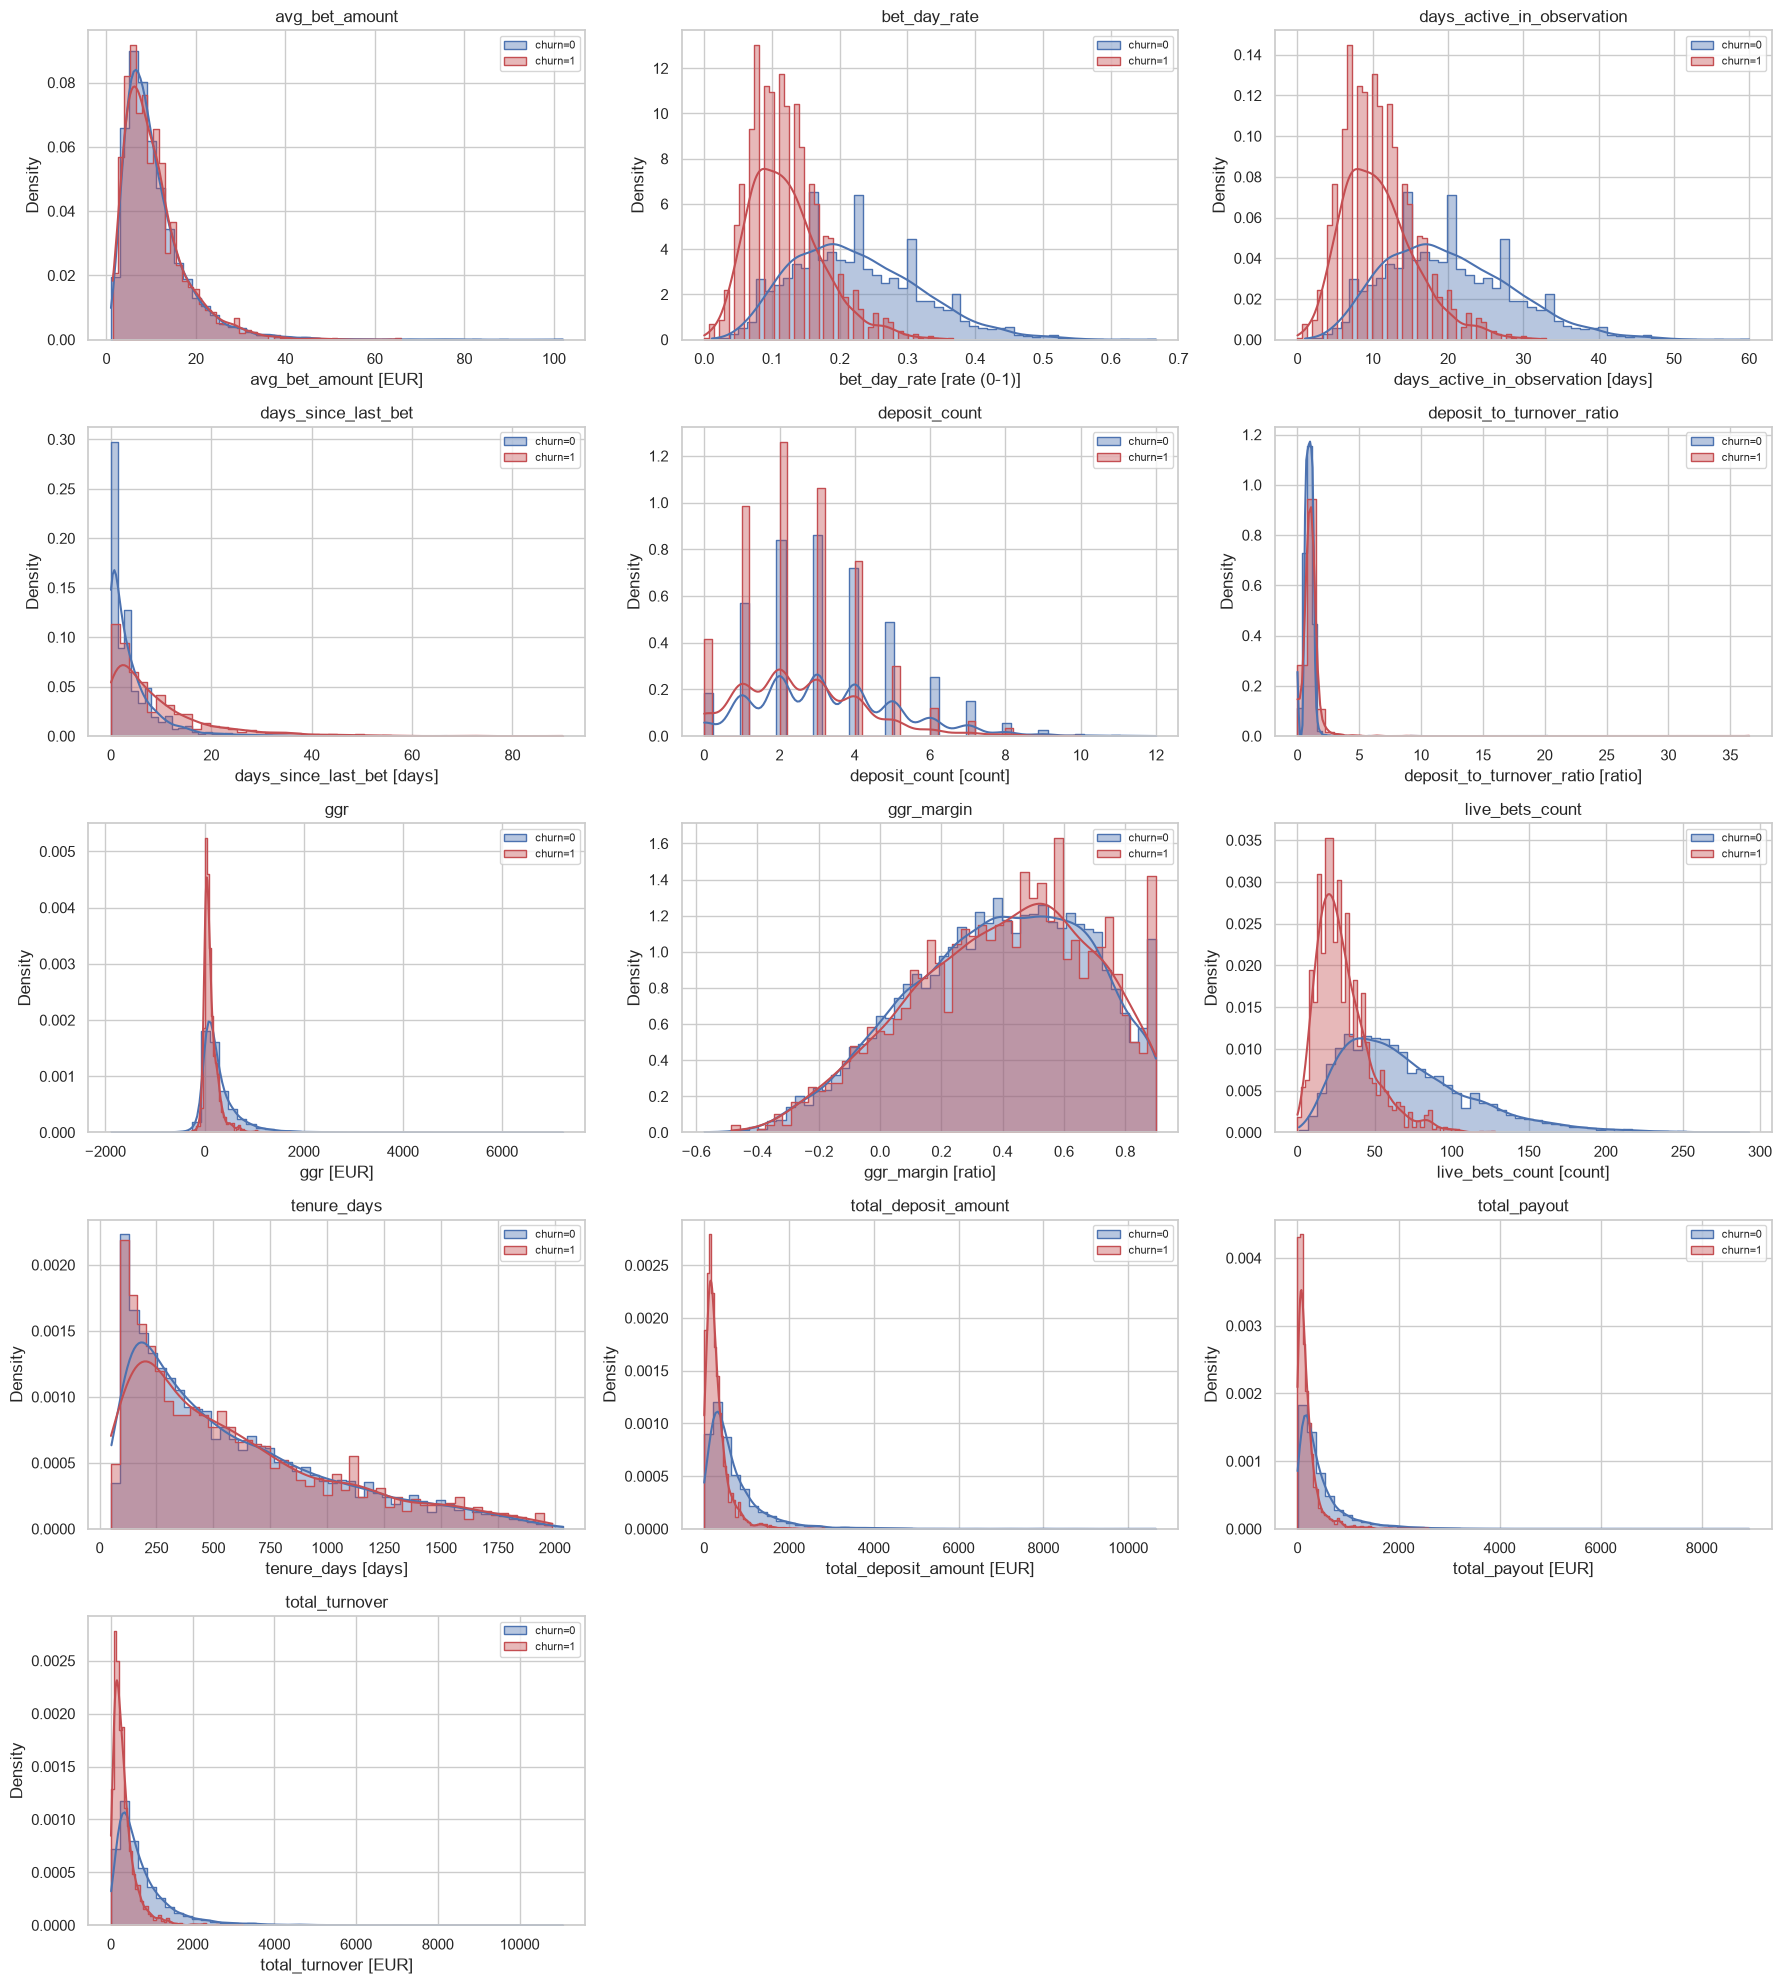

In [17]:
plot_distr(raw, num_cols, target=cfg.TARGET)

**Distribution vs churn**

* **Strong separators (shifted):** `days_since_last_bet` (recency), `bet_day_rate`, `days_active_in_observation`, `live_bets_count` (frequency/engagement). Churners concentrate at low engagement / high idle time.
* **Mild separators:** `deposit_count`, `total_turnover`, `total_deposit_amount`: churners lean lower but distributions largely overlap.
* **Weak / no standalone signal:** `avg_bet_amount`, `deposit_to_turnover_ratio`, `ggr`, `ggr_margin`, `total_payout`, `tenure_days` near identical class distributions.

* **Conclusion:** 
    * Confirms the RFM hierarchy. **Recency and Frequency** separate churn well. 
    * **Monetary** *totals* do not on their own. This motivates monetary engineering **intensity ratios** (per active day , per bet , per tenure, etc) rather than trusting raw totals.

### 2.6 What Drives Churn recency & engagement

Section 2.5 showed the classes *separate*; here I quantify the actual **churn rate** across
`days_since_last_bet` and `bet_day_rate`, the two RFM drivers.

- **Recency is strong and nonlinear:** churn climbs from ~11% (bet in last 3 days) to ~65% (idle 30+ days).
- **Engagement is strongly negative:** higher `bet_day_rate` quintiles churn far less.

This empirical monotonic pattern is the justification for the recency/frequency **intensity features**
engineered in Section 3.

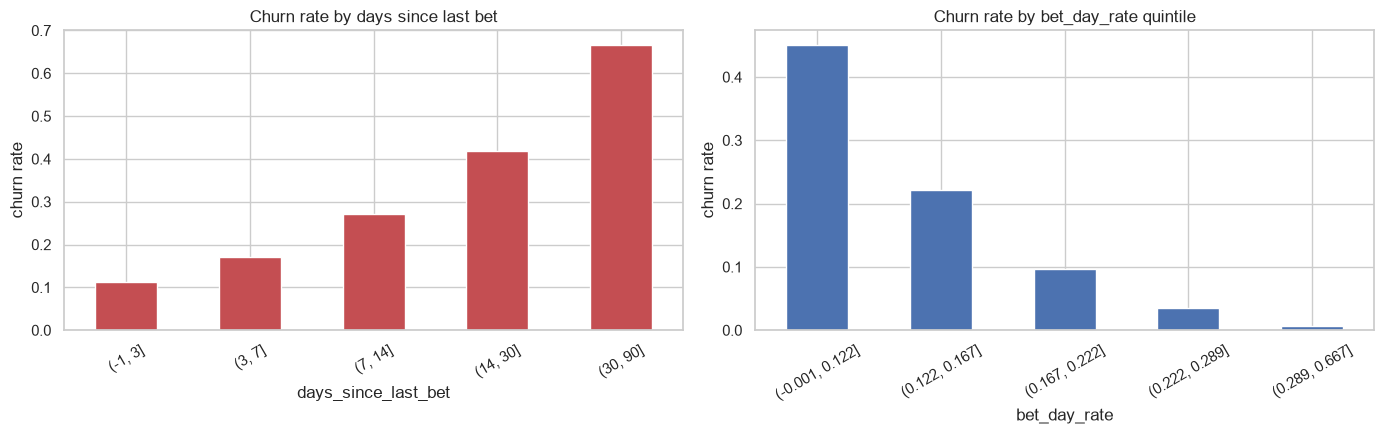

In [18]:
fig, axes = plt.subplots(1,2, figsize=(14,4.5))

rec = raw.groupby(pd.cut(raw.days_since_last_bet,[-1,3,7,14,30,90])).churn.mean()
rec.plot.bar(ax=axes[0], color="#C44E52")

axes[0].set_title("Churn rate by days since last bet")
axes[0].set_ylabel("churn rate") 
axes[0].tick_params(axis="x", rotation=30)

freq = raw.groupby(pd.qcut(raw.bet_day_rate, 5, duplicates="drop")).churn.mean()
freq.plot.bar(ax=axes[1], color="#4C72B0")

axes[1].set_title("Churn rate by bet_day_rate quintile")
axes[1].set_ylabel("churn rate")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### 2.7 Correlation

**Spearman**

- Here i am looking for spearman correlation between variables to make educated guess for skewed data. 
- This will be only used to help with feature engineering process, but for feature importance most impact will come from PR-AUC, SHAP, top-k analysis.

- Note for later analysis:
    - Near duplicate pair: days_active_in_observation ~ bet_day_rate (1.00). Likely mathematically derived from one another. 
    Solution would be to keep one, or engineer into a single feature.
    - live_bets_count strongly overlaps with the pair above (0.97 both). This should be candidate for consolidation into a single "activity/engagement" feature.
    - **(total_turnover, total_deposit_amount, total_payout, live_bets_count, bet_day_rate)** is internally correlated (0.6-0.9 range) 
      and also the strongest (negative) correlates of churn individually.

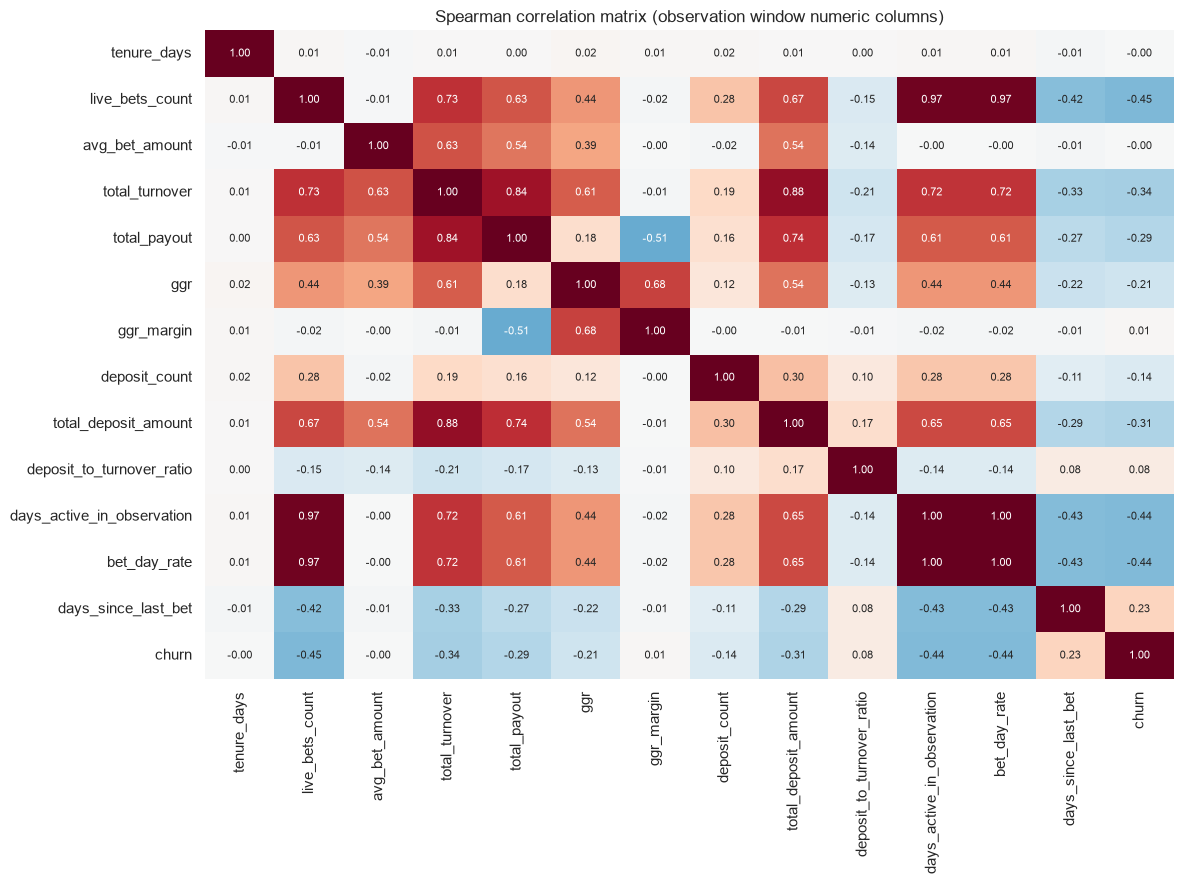

In [19]:
num = raw.select_dtypes("number").drop(columns=["live_bets_count_outcome_window"])

corr = num.corr(method="spearman")

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, square=False, annot=True, fmt=".2f", annot_kws={"size": 8}, cbar=False)

plt.title("Spearman correlation matrix (observation window numeric columns)")
plt.tight_layout()
plt.show()

### 2.8 Leakage audit.

Some features will be removed because they are predicting future or are answers to target variable.

So base on DATA_DICTIONARY.md:
- `live_bets_count_outcome_window` will be **DROPPED**. The target is literally derived from it. Using it is same as looking into the future.
- `observation_start/end_date` will be **DROPPED**. Constant for every row in this single snapshot so no signal.
- `registration_date`, `first/last_live_bet_date` will be **TRANSFORMED**. Raw dates are useless to the model. 
So it will be converted into numeric recency/tenure features, then dropped.
- `days_since_last_bet` will be **KEPT (watch)**. Measured at the snapshot; it is the strongest predictor. I will keep it but try it does not *entirely* dominate.

All of this is codded in `src/config.py::LEAKAGE_COLS` so it is auditable.

In [20]:
print("Dropped as leakage / constant:")
for c,why in cfg.LEAKAGE_COLS.items(): print(f"  - {c:32s} : {why}")

# Sanity check: the leakage column is almost a perfect proxy for the target.
print("\nAUC of raw 'outcome_window' count as a churn predictor (should be ~1.0 = obvious leak):")

from sklearn.metrics import roc_auc_score
print(round(roc_auc_score(raw.churn, -raw.live_bets_count_outcome_window), 4))

Dropped as leakage / constant:
  - live_bets_count_outcome_window   : target is derived from this column
  - observation_start_date           : constant (single snapshot)
  - observation_end_date             : constant (single snapshot)

AUC of raw 'outcome_window' count as a churn predictor (should be ~1.0 = obvious leak):
1.0


## 3.0 Feature Engineering (RFM framework)

This part will be engineered in `src/features.py`.

RFM  explanation (Recency, Frequency/engagement, Monetary/Value)

**Recency** *how long since active, relative to who they are*
- `recency_ratio` = idle days / tenure. 10 idle days means more for a 2 week old account than for a veteran.
- `days_since_first_bet`, `active_span_days` = onboarding age and how long their activity spanned.
- `last_bet_window_position` = how early in the window players went quiet.

**Frequency / engagement**
- `bets_per_active_day` = intensity when they do play.
- `activity_consistency` = active days spread across their span (steady vs one burst).

**Monetary / value**
- `turnover_per_active_day`, `turnover_per_bet`, `deposit_per_bet` = spend intensity normalised.
- `net_cash_flow` = deposits − payouts (operators cash view); `has_no_deposit`.
- `turnover_per_tenure_day`, `is_new_player` = value vs lifecycle stage.

Normalising raw counts by the players own tenure / active days lets a casual, newcomer and a heavy veteran be compared fairly.

In [25]:
df = load_clean()
feat = add_features(df)
new_cols = [c for c in feat.columns if c not in df.columns]

print("Engineered features:", new_cols)

feat[["user_id", "days_since_last_bet", "recency_ratio", "bets_per_active_day", "turnover_per_active_day", "net_cash_flow", "is_new_player"]].head()

Engineered features: ['recency_ratio', 'days_since_first_bet', 'active_span_days', 'last_bet_window_position', 'bets_per_active_day', 'activity_consistency', 'turnover_per_active_day', 'turnover_per_bet', 'deposit_per_bet', 'net_cash_flow', 'has_no_deposit', 'turnover_per_tenure_day', 'is_new_player']


,user_id,days_since_last_bet,recency_ratio,bets_per_active_day,turnover_per_active_day,net_cash_flow,is_new_player
0,USER_10000,5,0.026178,2.875000,5.836250,-27.74,0
1,USER_10001,10,0.020408,3.071429,16.032857,32.20,0
2,USER_10002,3,0.005848,3.076923,21.753846,188.82,0
3,USER_10003,0,0.000000,3.739130,38.700000,287.16,0
4,USER_10004,1,0.002092,3.416667,10.420833,-10.57,0


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   user_id                         10000 non-null  str           
 1   registration_date               10000 non-null  datetime64[us]
 2   observation_start_date          10000 non-null  datetime64[us]
 3   observation_end_date            10000 non-null  datetime64[us]
 4   last_live_bet_date              9999 non-null   datetime64[us]
 5   first_live_bet_date             9999 non-null   datetime64[us]
 6   tenure_days                     10000 non-null  int64         
 7   live_bets_count                 10000 non-null  int64         
 8   avg_bet_amount                  9999 non-null   float64       
 9   total_turnover                  10000 non-null  float64       
 10  total_payout                    10000 non-null  float64       
 11  ggr           

## 4.0 Modeling

### 4.1 Imports for modeling

In [38]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import lightgbm as lgb

#### 4.1.1 Modeling for raw features only.

In [ ]:
# df_raw_clean = load_clean()

# drop_cols = [cfg.TARGET, cfg.ID_COL] + cfg.DROP_AFTER_FEATURES + list(cfg.LEAKAGE_COLS.keys())

# X = df_raw_clean.drop(columns=[c for c in drop_cols if c in df_raw_clean.columns])
# y = df_raw_clean[cfg.TARGET].astype(int)

# X_tr, X_te, y_tr, y_te = train_test_split( X, y, test_size=0.2, stratify=y, random_state=cfg.RANDOM_STATE)

# print("train:", X_tr.shape, " test:", X_te.shape)

# logit = Pipeline([
#     ("imp", SimpleImputer(strategy="median")),
#     ("sc", StandardScaler()),
#     ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
# ])

# lgbm = lgb.LGBMClassifier( n_estimators=500, learning_rate=0.03, max_depth=3, num_leaves=8, 
#                           min_child_samples=150, subsample=0.8, colsample_bytree=0.8, 
#                           reg_lambda=1.0, random_state=cfg.RANDOM_STATE, verbose=-1
# )

In [ ]:
X_raw, y_raw = build_feature_matrix(load_clean(), feature_set="raw")

# Train/test split
X_raw_tr, X_raw_te, y_raw_tr, y_raw_te = train_test_split(X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=cfg.RANDOM_STATE)

print("RAW train:", X_raw_tr.shape, " test:", X_raw_te.shape)

# Baseline linear model (with impute + scale)
logit_raw = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=cfg.RANDOM_STATE)),
])

# Tree model
lgbm_raw = lgb.LGBMClassifier(
    n_estimators=500, 
    learning_rate=0.03, 
    max_depth=3,
    num_leaves=8,
    min_child_samples=150,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=cfg.RANDOM_STATE,
    verbose=-1
)

RAW train: (8000, 14)  test: (2000, 14)


#### 4.1.3 ALL DATA

In [33]:
X, y = build_feature_matrix(load_clean())
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=cfg.RANDOM_STATE)

print("train:", X_tr.shape, "  test:", X_te.shape)

logit = Pipeline([("imp", SimpleImputer(strategy="median")),
                  ("sc", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])

lgbm = lgb.LGBMClassifier(
    n_estimators=500, 
    learning_rate=0.03, 
    max_depth=3, 
    num_leaves=8,
    min_child_samples=150, 
    subsample=0.8, 
    colsample_bytree=0.8,
    reg_lambda=1.0, 
    random_state=cfg.RANDOM_STATE, 
    verbose=-1
)

train: (8000, 27)   test: (2000, 27)


### 4.2 Cross Validation stability check

In [30]:
cv = StratifiedKFold(5, shuffle=True, random_state=cfg.RANDOM_STATE)

RAW FEATURES

In [31]:
scores_raw = {}

for name, mdl in [("LogReg_raw", logit_raw), ("LightGBM_raw", lgbm_raw)]:
    scores_raw[f"{name} ROC-AUC"] = cross_val_score(mdl, X_raw_tr, y_raw_tr, cv=cv, scoring="roc_auc")
    scores_raw[f"{name} PR-AUC"]  = cross_val_score(mdl, X_raw_tr, y_raw_tr, cv=cv, scoring="average_precision")

ev.cv_stability(scores_raw)

,mean,std
LogReg_raw ROC-AUC,0.8364,0.0038
LogReg_raw PR-AUC,0.5047,0.0149
LightGBM_raw ROC-AUC,0.8315,0.0027
LightGBM_raw PR-AUC,0.4873,0.0124


ALL FEATURES

In [34]:
scores = {}

for name, mdl in [("LogReg", logit), ("LightGBM", lgbm)]:
    scores[f"{name} ROC-AUC"] = cross_val_score(mdl, X_tr, y_tr, cv=cv, scoring="roc_auc")
    scores[f"{name} PR-AUC"]  = cross_val_score(mdl, X_tr, y_tr, cv=cv, scoring="average_precision")
    
ev.cv_stability(scores)

,mean,std
LogReg ROC-AUC,0.8353,0.0039
LogReg PR-AUC,0.5002,0.0122
LightGBM ROC-AUC,0.8294,0.0024
LightGBM PR-AUC,0.4845,0.0116


### 4.3 Fit on train, evaluate on the held-out test set

RAW FEATURES ONLY

In [32]:
logit_raw.fit(X_raw_tr, y_raw_tr)
lgbm_raw.fit(X_raw_tr, y_raw_tr)

p_lr_raw = logit_raw.predict_proba(X_raw_te)[:, 1]
p_gb_raw = lgbm_raw.predict_proba(X_raw_te)[:, 1]

res_raw = pd.DataFrame({
    "LogReg_raw": ev.threshold_free_metrics(y_raw_te, p_lr_raw),
    "LightGBM_raw": ev.threshold_free_metrics(y_raw_te, p_gb_raw),
}).T
display(res_raw.round(4))

,roc_auc,pr_auc,brier
LogReg_raw,0.855,0.5347,0.1626
LightGBM_raw,0.852,0.5212,0.1062


ALL FEATURES

In [35]:
logit.fit(X_tr, y_tr)
lgbm.fit(X_tr, y_tr)

p_lr = logit.predict_proba(X_te)[:,1]
p_gb = lgbm.predict_proba(X_te)[:,1]

res = pd.DataFrame({"LogReg": ev.threshold_free_metrics(y_te, p_lr), "LightGBM": ev.threshold_free_metrics(y_te, p_gb)}).T
res.round(4)

,roc_auc,pr_auc,brier
LogReg,0.8550,0.5333,0.1621
LightGBM,0.8481,0.5104,0.1078


## 5. Evaluation

### 5.1 ROC & Precision-Recall curves

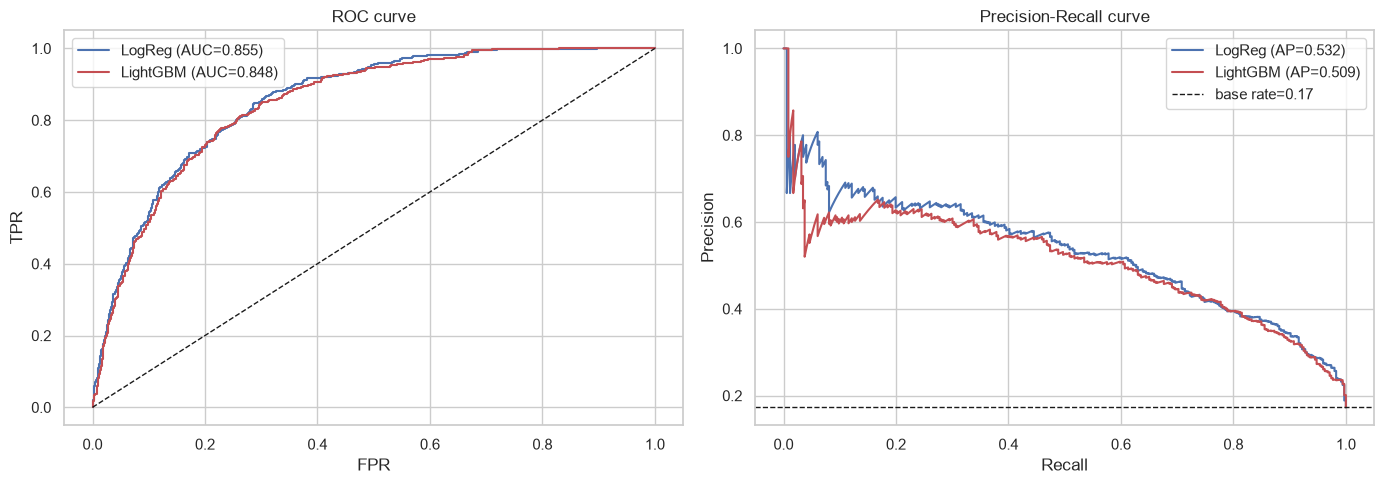

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1,2, figsize=(14,5))

for name,p,c in [("LogReg",p_lr,"#4C72B0"),("LightGBM",p_gb,"#C44E52")]:
    fpr,tpr,_ = roc_curve(y_te,p); axes[0].plot(fpr,tpr,label=f"{name} (AUC={auc(fpr,tpr):.3f})", color=c)
    pr,rc,_ = precision_recall_curve(y_te,p); axes[1].plot(rc,pr,label=f"{name} (AP={auc(rc,pr):.3f})", color=c)

axes[0].plot([0,1],[0,1],"k--",lw=1)
axes[0].set(xlabel="FPR",ylabel="TPR",title="ROC curve")
axes[0].legend()
axes[1].axhline(y_te.mean(),ls="--",c="k",lw=1,label=f"base rate={y_te.mean():.2f}")
axes[1].set(xlabel="Recall",ylabel="Precision",title="Precision-Recall curve")
axes[1].legend()

plt.tight_layout() 
plt.show()

In [36]:
res_all = res.copy()

eval_compare = pd.concat(
    [
        res_raw.rename_axis("model").reset_index().assign(feature_set="raw"),
        res_all.rename_axis("model").reset_index().assign(feature_set="all"),
    ],
    ignore_index=True
)

# Keep PR first (primary), ROC second (secondary)
eval_compare = eval_compare[["feature_set", "model", "pr_auc", "roc_auc", "brier"]]
eval_compare = eval_compare.sort_values(["pr_auc", "roc_auc"], ascending=False)

display(eval_compare.round(4))

,feature_set,model,pr_auc,roc_auc,brier
0,raw,LogReg_raw,0.5347,0.8550,0.1626
2,all,LogReg,0.5333,0.8550,0.1621
1,raw,LightGBM_raw,0.5212,0.8520,0.1062
3,all,LightGBM,0.5104,0.8481,0.1078


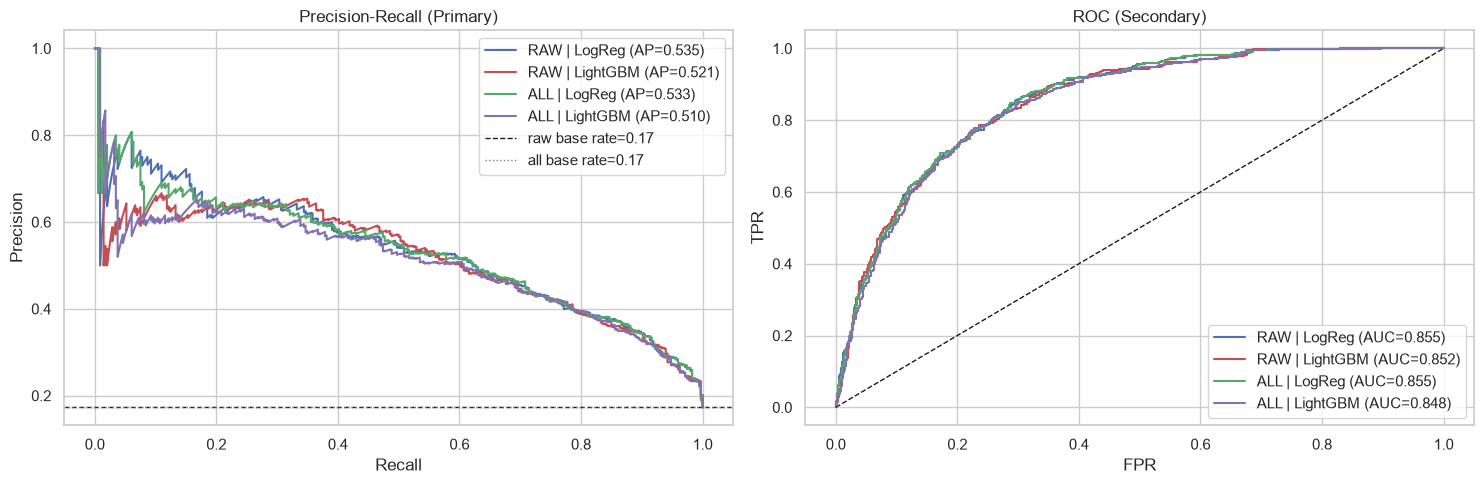

In [40]:
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score, roc_auc_score

# Collect all prediction sets in one place
pred_sets = [
    ("RAW | LogReg", y_raw_te, p_lr_raw, "#4C72B0"),
    ("RAW | LightGBM", y_raw_te, p_gb_raw, "#C44E52"),
    ("ALL | LogReg", y_te, p_lr, "#55A868"),
    ("ALL | LightGBM", y_te, p_gb, "#8172B2"),
]

# PR first (primary), ROC second (secondary)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for name, y_true, p, color in pred_sets:
    # PR curve
    precision, recall, _ = precision_recall_curve(y_true, p)
    ap = average_precision_score(y_true, p)
    axes[0].plot(recall, precision, label=f"{name} (AP={ap:.3f})", color=color)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, p)
    ra = roc_auc_score(y_true, p)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={ra:.3f})", color=color)

# Baseline lines
axes[0].axhline(y_raw_te.mean(), ls="--", c="k", lw=1, label=f"raw base rate={y_raw_te.mean():.2f}")
axes[0].axhline(y_te.mean(), ls=":", c="gray", lw=1, label=f"all base rate={y_te.mean():.2f}")

axes[1].plot([0, 1], [0, 1], "k--", lw=1)

axes[0].set(title="Precision-Recall (Primary)", xlabel="Recall", ylabel="Precision")
axes[1].set(title="ROC (Secondary)", xlabel="FPR", ylabel="TPR")

axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

### 5.2 Retention targeting, lift @ top-k


In [30]:
ev.topk_report(y_te, p_gb)

,top_k,n_contacted,precision,recall,lift
0,5%,100,0.640,0.185,3.70
1,10%,200,0.595,0.344,3.44
2,20%,400,0.505,0.584,2.92


In [41]:
# 5.2 Retention targeting, lift @ top-k (RAW vs ALL, LightGBM)

topk_raw_gb = ev.topk_report(y_raw_te, p_gb_raw).assign(
    feature_set="raw",
    model="LightGBM_raw"
)

topk_all_gb = ev.topk_report(y_te, p_gb).assign(
    feature_set="all",
    model="LightGBM_all"
)

topk_compare_gb = pd.concat([topk_raw_gb, topk_all_gb], ignore_index=True)
topk_compare_gb = topk_compare_gb[
    ["feature_set", "model", "top_k", "n_contacted", "precision", "recall", "lift"]
]

display(topk_compare_gb)

,feature_set,model,top_k,n_contacted,precision,recall,lift
0,raw,LightGBM_raw,5%,100,0.630,0.182,3.64
1,raw,LightGBM_raw,10%,200,0.630,0.364,3.64
2,raw,LightGBM_raw,20%,400,0.505,0.584,2.92
3,all,LightGBM_all,5%,100,0.640,0.185,3.70
4,all,LightGBM_all,10%,200,0.595,0.344,3.44
5,all,LightGBM_all,20%,400,0.505,0.584,2.92


In [42]:
# 5.2 Retention targeting, lift @ top-k (RAW vs ALL, both models)

topk_frames = [
    ev.topk_report(y_raw_te, p_lr_raw).assign(feature_set="raw", model="LogReg_raw"),
    ev.topk_report(y_raw_te, p_gb_raw).assign(feature_set="raw", model="LightGBM_raw"),
    ev.topk_report(y_te, p_lr).assign(feature_set="all", model="LogReg_all"),
    ev.topk_report(y_te, p_gb).assign(feature_set="all", model="LightGBM_all"),
]

topk_compare = pd.concat(topk_frames, ignore_index=True)
topk_compare = topk_compare[
    ["feature_set", "model", "top_k", "n_contacted", "precision", "recall", "lift"]
]

display(topk_compare.sort_values(["top_k", "lift"], ascending=[True, False]))

,feature_set,model,top_k,n_contacted,precision,recall,lift
4,raw,LightGBM_raw,10%,200,0.630,0.364,3.64
1,raw,LogReg_raw,10%,200,0.620,0.358,3.58
7,all,LogReg_all,10%,200,0.615,0.355,3.55
10,all,LightGBM_all,10%,200,0.595,0.344,3.44
2,raw,LogReg_raw,20%,400,0.518,0.598,2.99
8,all,LogReg_all,20%,400,0.518,0.598,2.99
5,raw,LightGBM_raw,20%,400,0.505,0.584,2.92
11,all,LightGBM_all,20%,400,0.505,0.584,2.92
6,all,LogReg_all,5%,100,0.650,0.188,3.76
0,raw,LogReg_raw,5%,100,0.640,0.185,3.70


### 5.3 Calibration


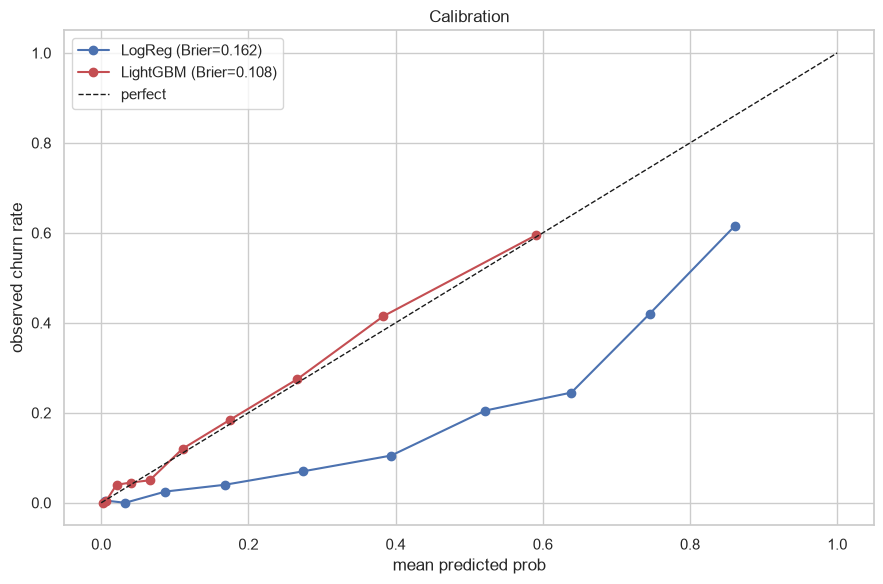

In [34]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(9,6))

for name,p,c in [("LogReg",p_lr,"#4C72B0"),("LightGBM",p_gb,"#C44E52")]:
    fo,mp = calibration_curve(y_te,p,n_bins=10,strategy="quantile")
    plt.plot(mp,fo,"o-",label=f"{name} (Brier={ev.threshold_free_metrics(y_te,p)['brier']:.3f})",color=c)

plt.plot([0,1],[0,1],"k--",lw=1,label="perfect")
plt.xlabel("mean predicted prob")
plt.ylabel("observed churn rate")
plt.title("Calibration")
plt.legend()

plt.tight_layout()
plt.show()

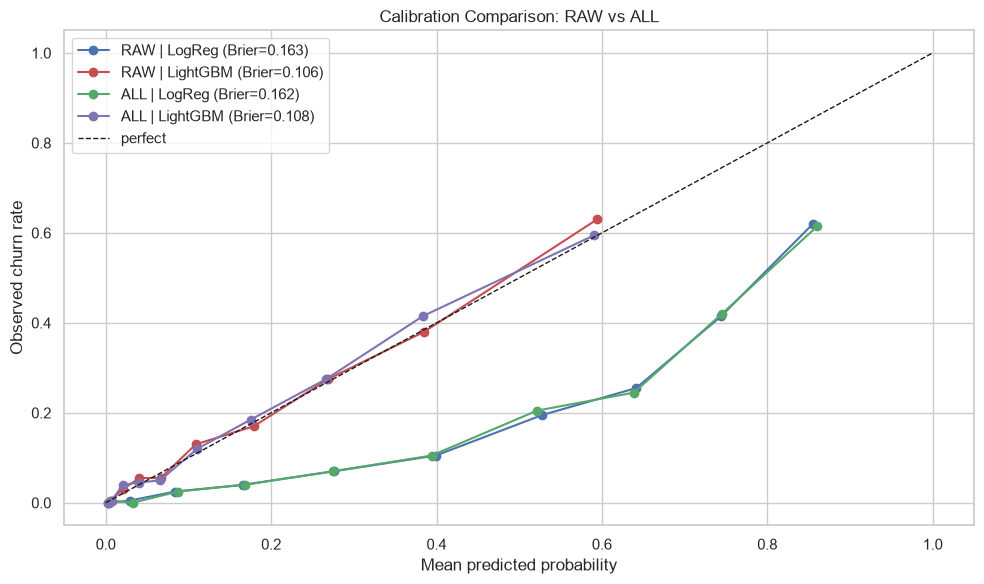

In [43]:
from sklearn.calibration import calibration_curve

# Collect prediction sets (RAW + ALL, both models)
cal_sets = [
    ("RAW | LogReg", y_raw_te, p_lr_raw, "#4C72B0"),
    ("RAW | LightGBM", y_raw_te, p_gb_raw, "#C44E52"),
    ("ALL | LogReg", y_te, p_lr, "#55A868"),
    ("ALL | LightGBM", y_te, p_gb, "#8172B2"),
]

plt.figure(figsize=(10, 6))

for name, y_true, p, color in cal_sets:
    frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=10, strategy="quantile")
    brier = ev.threshold_free_metrics(y_true, p)["brier"]
    plt.plot(mean_pred, frac_pos, "o-", color=color, label=f"{name} (Brier={brier:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed churn rate")
plt.title("Calibration Comparison: RAW vs ALL")
plt.legend()
plt.tight_layout()
plt.show()

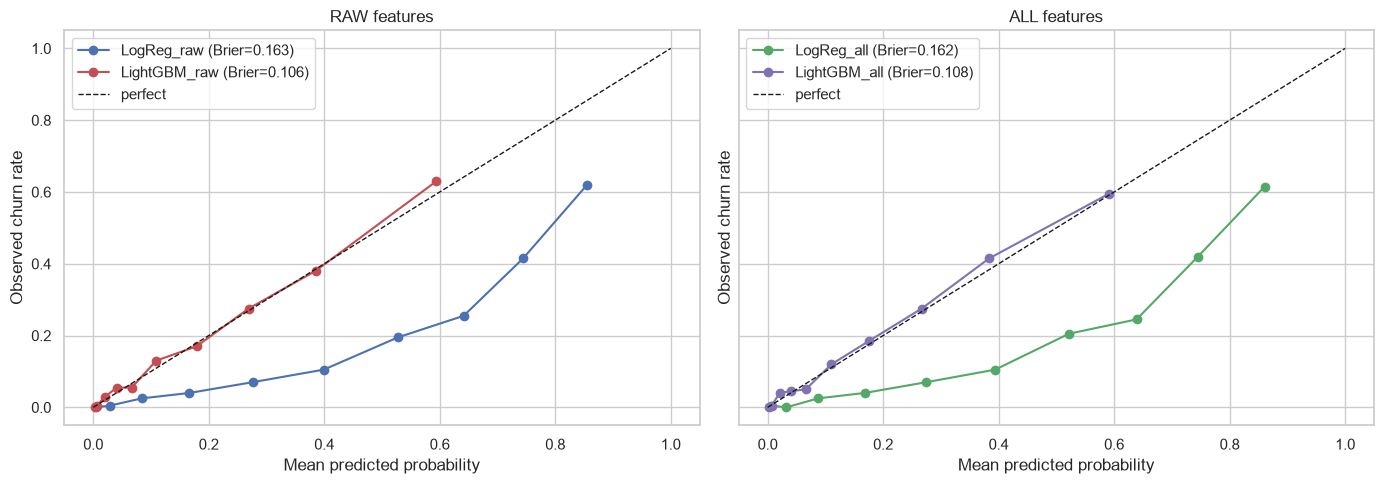

In [44]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

raw_sets = [
    ("LogReg_raw", y_raw_te, p_lr_raw, "#4C72B0"),
    ("LightGBM_raw", y_raw_te, p_gb_raw, "#C44E52"),
]
all_sets = [
    ("LogReg_all", y_te, p_lr, "#55A868"),
    ("LightGBM_all", y_te, p_gb, "#8172B2"),
]

for name, y_true, p, color in raw_sets:
    frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=10, strategy="quantile")
    brier = ev.threshold_free_metrics(y_true, p)["brier"]
    axes[0].plot(mean_pred, frac_pos, "o-", color=color, label=f"{name} (Brier={brier:.3f})")

for name, y_true, p, color in all_sets:
    frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=10, strategy="quantile")
    brier = ev.threshold_free_metrics(y_true, p)["brier"]
    axes[1].plot(mean_pred, frac_pos, "o-", color=color, label=f"{name} (Brier={brier:.3f})")

for ax, title in zip(axes, ["RAW features", "ALL features"]):
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
    ax.set_title(title)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed churn rate")
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Explainability, SHAP

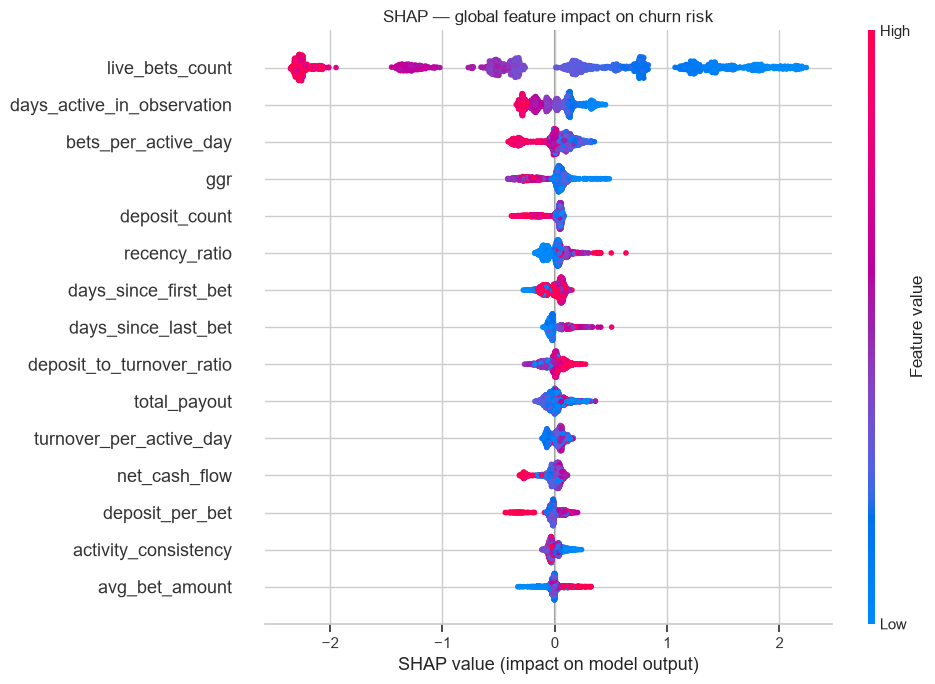

In [35]:
import shap

explainer = shap.TreeExplainer(lgbm)

sv = explainer.shap_values(X_te)
sv1 = sv[1] if isinstance(sv, list) else sv   # positive class

shap.summary_plot(sv1, X_te, show=False, max_display=15, plot_size=(10,7))
plt.title("SHAP — global feature impact on churn risk")
plt.tight_layout()
plt.show()